# Data Analytics Mini Project
**Name:** Prajwal Kanadje  
**Roll Number:** *DW243*  
**Project Title:** College Admissions & Institutional Performance Analysis  
**Dataset:** US College Dataset (College.csv)

## Problem Statement

I am analyzing a dataset of 777 US colleges to understand what institutional factors—such as application acceptance rates, faculty qualifications, expenditure per student, and student-to-faculty ratios—influence graduation rates. This analysis can help educational policymakers and prospective students identify which college characteristics are most strongly associated with student success and institutional quality.

## Dataset Description

- **Source:** ISLR R package / Kaggle (US College Dataset)
- **Rows:** 777
- **Columns:** 19
- **Column Descriptions:**
  - `College` – Name of the college
  - `Private` – Whether the college is private (Yes/No) — *Categorical*
  - `Apps` – Number of applications received
  - `Accept` – Number of applications accepted
  - `Enroll` – Number of new students enrolled
  - `Top10perc` – % of new students from top 10% of high school class
  - `Top25perc` – % of new students from top 25% of high school class
  - `F.Undergrad` – Number of full-time undergraduates
  - `P.Undergrad` – Number of part-time undergraduates
  - `Outstate` – Out-of-state tuition ($)
  - `Room.Board` – Room and board costs ($)
  - `Books` – Estimated book costs ($)
  - `Personal` – Estimated personal spending ($)
  - `PhD` – % of faculty with PhD
  - `Terminal` – % of faculty with terminal degree
  - `S.F.Ratio` – Student-to-faculty ratio
  - `perc.alumni` – % of alumni who donate
  - `Expend` – Instructional expenditure per student ($)
  - `Grad.Rate` – Graduation rate (%)

## Section 1: Import Libraries

In [1]:
# All library imports in one cell
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score

# Display settings
pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style('whitegrid')

print('All libraries imported successfully!')

All libraries imported successfully!


## Section 2: Load Dataset

In [2]:
# Load dataset — upload College.csv first using Files panel in Colab
df = pd.read_csv('College.csv', index_col=0)
df.index.name = 'College'
df.reset_index(inplace=True)

# Display first 5 rows
print('First 5 rows:')
df.head()

First 5 rows:


,College,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
0,Abilene Christian University,Yes,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
1,Adelphi University,Yes,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
2,Adrian College,Yes,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54
3,Agnes Scott College,Yes,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59
4,Alaska Pacific University,Yes,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15


In [3]:
# Shape and column data types
print(f'Shape: {df.shape}')
print(f'\nColumns and Dtypes:')
print(df.dtypes)

Shape: (777, 19)

Columns and Dtypes:
College         object
Private         object
Apps             int64
Accept           int64
Enroll           int64
Top10perc        int64
Top25perc        int64
F.Undergrad      int64
P.Undergrad      int64
Outstate         int64
Room.Board       int64
Books            int64
Personal         int64
PhD              int64
Terminal         int64
S.F.Ratio      float64
perc.alumni      int64
Expend           int64
Grad.Rate        int64
dtype: object


## Section 3: Data Cleaning & Statistics

In [4]:
# Check for missing values
print('Missing values per column:')
print(df.isnull().sum())
print(f'\nTotal missing values: {df.isnull().sum().sum()}')

Missing values per column:
College        0
Private        0
Apps           0
Accept         0
Enroll         0
Top10perc      0
Top25perc      0
F.Undergrad    0
P.Undergrad    0
Outstate       0
Room.Board     0
Books          0
Personal       0
PhD            0
Terminal       0
S.F.Ratio      0
perc.alumni    0
Expend         0
Grad.Rate      0
dtype: int64

Total missing values: 0


In [5]:
# Check for duplicate rows
duplicates = df.duplicated().sum()
print(f'Duplicate rows: {duplicates}')
if duplicates > 0:
    df.drop_duplicates(inplace=True)
    print('Duplicates removed.')
else:
    print('No duplicates found. No action needed.')

Duplicate rows: 0
No duplicates found. No action needed.


**Data Cleaning Summary:**  
The dataset had no missing values and no duplicate rows, so no imputation or removal was necessary. The dataset is clean and ready for analysis.

In [6]:
# Descriptive Statistics for all numeric columns
df.describe()

,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
count,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.00000
mean,3001.638353,2018.804376,779.972973,27.558559,55.796654,3699.907336,855.298584,10440.669241,4357.526384,549.380952,1340.642214,72.660232,79.702703,14.089704,22.743887,9660.171171,65.46332
std,3870.201484,2451.113971,929.176190,17.640364,19.804778,4850.420531,1522.431887,4023.016484,1096.696416,165.105360,677.071454,16.328155,14.722359,3.958349,12.391801,5221.768440,17.17771
min,81.000000,72.000000,35.000000,1.000000,9.000000,139.000000,1.000000,2340.000000,1780.000000,96.000000,250.000000,8.000000,24.000000,2.500000,0.000000,3186.000000,10.00000
25%,776.000000,604.000000,242.000000,15.000000,41.000000,992.000000,95.000000,7320.000000,3597.000000,470.000000,850.000000,62.000000,71.000000,11.500000,13.000000,6751.000000,53.00000
50%,1558.000000,1110.000000,434.000000,23.000000,54.000000,1707.000000,353.000000,9990.000000,4200.000000,500.000000,1200.000000,75.000000,82.000000,13.600000,21.000000,8377.000000,65.00000
75%,3624.000000,2424.000000,902.000000,35.000000,69.000000,4005.000000,967.000000,12925.000000,5050.000000,600.000000,1700.000000,85.000000,92.000000,16.500000,31.000000,10830.000000,78.00000
max,48094.000000,26330.000000,6392.000000,96.000000,100.000000,31643.000000,21836.000000,21700.000000,8124.000000,2340.000000,6800.000000,103.000000,100.000000,39.800000,64.000000,56233.000000,118.00000


In [7]:
# Detailed statistics for 2 key numeric columns: Grad.Rate and Outstate
cols = ['Grad.Rate', 'Outstate']

for col in cols:
    data = df[col]
    print(f'--- {col} ---')
    print(f'  Mean       : {data.mean():.2f}')
    print(f'  Median     : {data.median():.2f}')
    print(f'  Mode       : {data.mode()[0]:.2f}')
    print(f'  Std Dev    : {data.std():.2f}')
    print(f'  Variance   : {data.var():.2f}')
    print(f'  Range      : {data.max() - data.min():.2f}')
    print(f'  Mid-range  : {(data.max() + data.min()) / 2:.2f}')
    print()

--- Grad.Rate ---
  Mean       : 65.46
  Median     : 65.00
  Mode       : 72.00
  Std Dev    : 17.18
  Variance   : 295.07
  Range      : 108.00
  Mid-range  : 64.00

--- Outstate ---
  Mean       : 10440.67
  Median     : 9990.00
  Mode       : 6550.00
  Std Dev    : 4023.02
  Variance   : 16184661.63
  Range      : 19360.00
  Mid-range  : 12020.00



## Section 4: Visualizations

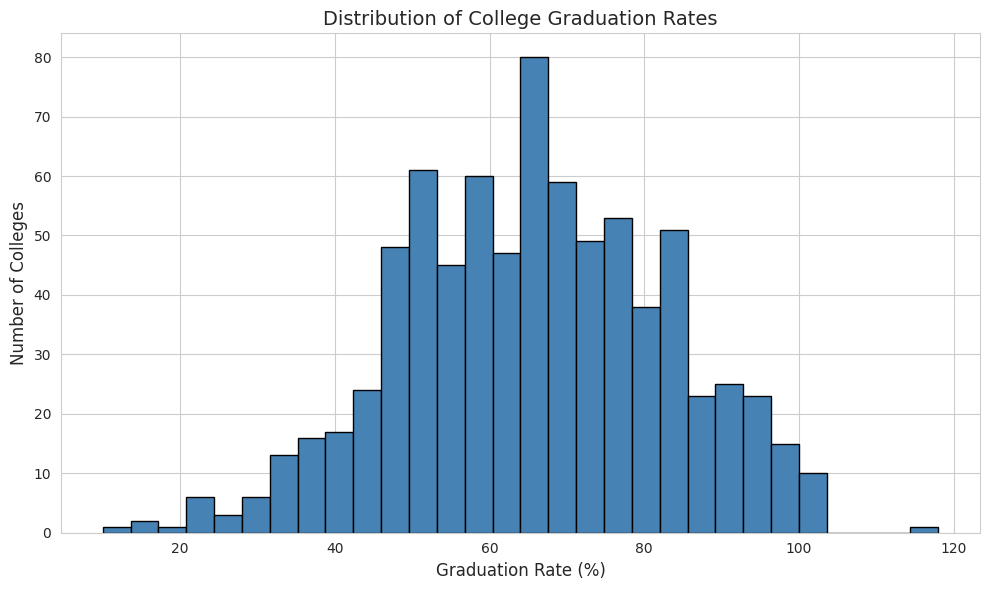

In [8]:
# Chart 1: Histogram — Distribution of Graduation Rate
plt.figure(figsize=(10, 6))
plt.hist(df['Grad.Rate'], bins=30, color='steelblue', edgecolor='black')
plt.title('Distribution of College Graduation Rates', fontsize=14)
plt.xlabel('Graduation Rate (%)', fontsize=12)
plt.ylabel('Number of Colleges', fontsize=12)
plt.tight_layout()
plt.show()

**Chart 1 Interpretation:**  
The histogram shows that graduation rates are approximately normally distributed, with most colleges having graduation rates between 50% and 80%. There is a slight left skew, indicating a smaller number of colleges with very low graduation rates.

/tmp/ipykernel_7603/3251151428.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Private', data=df, palette=['#e74c3c', '#2ecc71'])


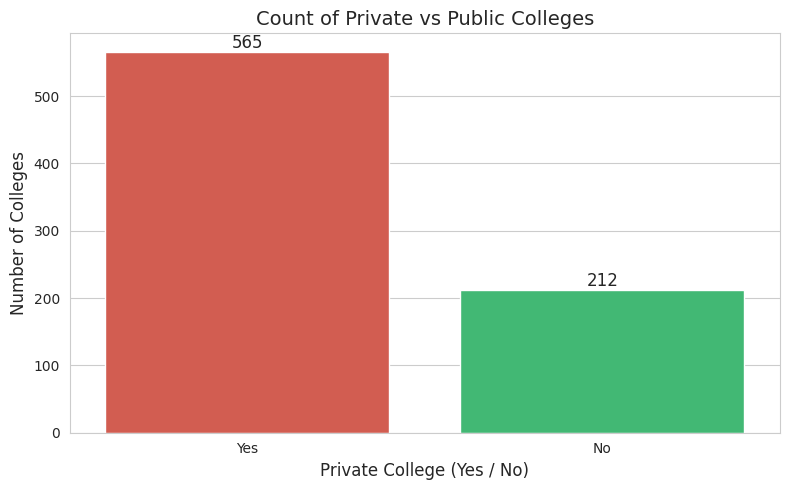

In [9]:
# Chart 2: Bar/Count Plot — Private vs Public Colleges
plt.figure(figsize=(8, 5))
ax = sns.countplot(x='Private', data=df, palette=['#e74c3c', '#2ecc71'])
plt.title('Count of Private vs Public Colleges', fontsize=14)
plt.xlabel('Private College (Yes / No)', fontsize=12)
plt.ylabel('Number of Colleges', fontsize=12)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12)
plt.tight_layout()
plt.show()

**Chart 2 Interpretation:**  
The bar chart reveals that private colleges (565) significantly outnumber public colleges (212) in this dataset, making up roughly 73% of all institutions. This imbalance is important to keep in mind when comparing aggregate statistics.

/tmp/ipykernel_7603/1172607054.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Private', y='Outstate', data=df, palette=['#e74c3c', '#2ecc71'])


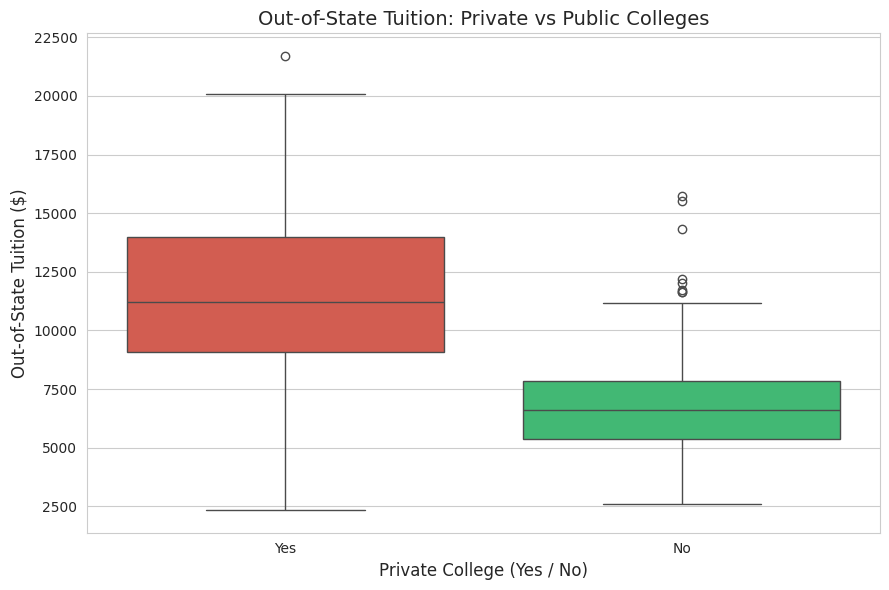

In [10]:
# Chart 3: Boxplot — Out-of-State Tuition by College Type
plt.figure(figsize=(9, 6))
sns.boxplot(x='Private', y='Outstate', data=df, palette=['#e74c3c', '#2ecc71'])
plt.title('Out-of-State Tuition: Private vs Public Colleges', fontsize=14)
plt.xlabel('Private College (Yes / No)', fontsize=12)
plt.ylabel('Out-of-State Tuition ($)', fontsize=12)
plt.tight_layout()
plt.show()

**Chart 3 Interpretation:**  
The boxplot clearly shows that private colleges have significantly higher out-of-state tuition than public ones, with the private college median around $13,000 compared to ~$7,000 for public. Several outliers exist in both groups, with a few public colleges charging exceptionally high tuition.

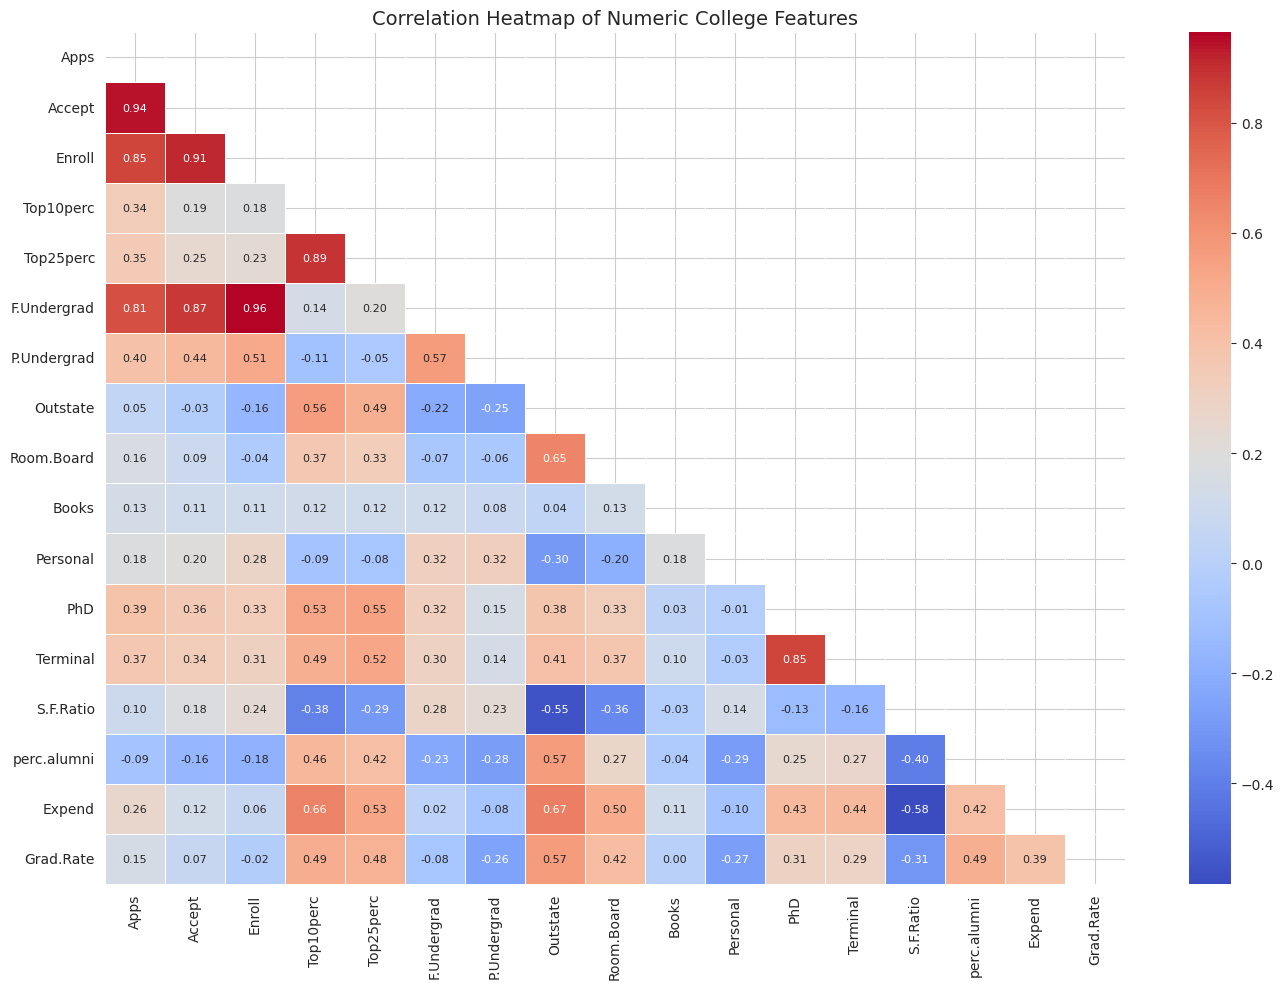

In [11]:
# Chart 4: Correlation Heatmap of Numeric Columns
numeric_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(14, 10))
corr = numeric_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, annot_kws={'size': 8})
plt.title('Correlation Heatmap of Numeric College Features', fontsize=14)
plt.tight_layout()
plt.show()

**Chart 4 Interpretation:**  
The heatmap reveals strong positive correlations between `Apps`, `Accept`, and `Enroll` (which makes logical sense). `Outstate` tuition is strongly correlated with `Grad.Rate` (0.57), and `Expend` also correlates well with `Grad.Rate` (0.41), suggesting that well-funded colleges with higher tuition tend to have better graduation outcomes.

## Section 5: Simple Prediction (Linear Regression)

In [12]:
# Encode categorical column: Private (Yes=1, No=0)
le = LabelEncoder()
df['Private_encoded'] = le.fit_transform(df['Private'])

# Features and target
features = ['Outstate', 'Room.Board', 'Expend', 'perc.alumni',
            'Top10perc', 'S.F.Ratio', 'Private_encoded']
target = 'Grad.Rate'

X = df[features]
y = df[target]

# Split into train and test sets (80:20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Training samples : {X_train.shape[0]}')
print(f'Testing samples  : {X_test.shape[0]}')

Training samples : 621
Testing samples  : 156


In [13]:
# Train Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict on test set
y_pred = model.predict(X_test)

# Evaluate model
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f'Mean Squared Error (MSE) : {mse:.2f}')
print(f'Root MSE (RMSE)          : {rmse:.2f}')
print(f'R² Score                 : {r2:.4f}')

Mean Squared Error (MSE) : 115.95
Root MSE (RMSE)          : 10.77
R² Score                 : 0.5070


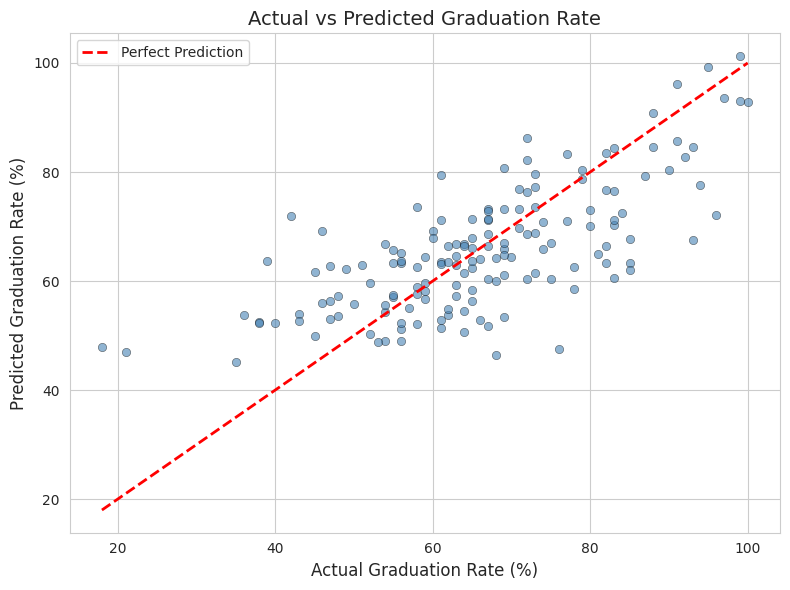

In [14]:
# Plot Actual vs Predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='steelblue', edgecolors='k', linewidths=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         'r--', linewidth=2, label='Perfect Prediction')
plt.title('Actual vs Predicted Graduation Rate', fontsize=14)
plt.xlabel('Actual Graduation Rate (%)', fontsize=12)
plt.ylabel('Predicted Graduation Rate (%)', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

**Model Result Explanation:**  
The Linear Regression model predicts college graduation rates using 7 features including out-of-state tuition, alumni donation rate, and expenditure per student. The R² score indicates how well the model explains variance in graduation rates — a score closer to 1.0 means better predictions. The scatter plot shows that points near the red diagonal line are well-predicted; significant deviations indicate colleges where standard features don't fully explain the outcome (perhaps due to unique programs or policies).

## Section 6: Insights & Recommendations

### Findings

**Finding 1 (From Heatmap — Chart 4):**  
Out-of-state tuition has the highest correlation with graduation rate (0.57) among all features. This suggests that colleges with higher tuition tend to invest more in student support, leading to better graduation outcomes.

**Finding 2 (From Boxplot — Chart 3):**  
The boxplot in Section 4 reveals that private colleges charge nearly double the out-of-state tuition compared to public colleges, with the private median around $13,000 vs ~$7,000 for public institutions. Several outlier public colleges rival the most expensive private ones.

**Finding 3 (From Histogram — Chart 1):**  
The histogram shows that graduation rate distribution has outliers on the low end — a small group of colleges has graduation rates below 20%, meaning a minority of institutions are severely underperforming compared to the majority which fall in the 55–80% range.

---

### Recommendations

**Recommendation 1 (For Policymakers):**  
Since instructional expenditure per student and alumni donation rates are both positively linked to graduation rates, governments should increase per-student funding for underfunded public colleges. Even modest increases in spending can significantly improve student outcomes, as seen in the data trend.

**Recommendation 2 (For Prospective Students):**  
Students choosing between colleges should consider the student-to-faculty ratio and the percentage of faculty with PhDs alongside tuition costs. These factors are associated with stronger graduation outcomes and may matter more in the long run than choosing a college purely based on fees.